In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import scipy.cluster.hierarchy as sch

from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
## Group - 1 data i.e Good = 1
#data1 = {
#    'Permeability' : [20, 23, 22, 27, 21, 17, 13],
#    'LDL_uptake': [1.2, 1.1, 1.4, 1.2, 1.8, 1.3, 1.7],
#    'Total_ROS': [1, 0.9, 1.1, 1.2, 0.8, 0.9, 0.7],
#    'Vascular_Marker' : [100, 98, 96, 90, 92, 96, 100],
#    'Cell_Signalling': [80, 78, 85, 89, 95, 88, 92],
#    'Tube_formation': [100, 98, 99, 90, 96, 92, 97],
#    'In_vivo_recovery': [70, 78, 79, 83, 82, 72, 71],
#    'Group': [1]*7                                        # 1 is Good
#}

In [3]:
## Group - 2 data i.e. Bad = 0
#data2 = {
#    'Permeability' : [67, 69, 71, 75, 68, 79, 70],
#    'LDL_uptake': [0.3, 2, 0.3, 0.22, 0.34, 0.19, 0.35],
#    'Total_ROS': [1.9, 2.2, 1.8, 2, 1.9, 1.8, 2.1],
#    'Vascular_Marker' : [77, 74, 68, 81, 75, 70, 69],
#    'Cell_Signalling': [50, 55, 43, 49, 47, 43, 59],
#    'Tube_formation': [40, 44, 39, 32, 35, 41, 46],
#    'In_vivo_recovery': [25, 19, 35, 32, 34, 28, 22],
#    'Group': [0]*7                                      # 0 is Bad
#}

In [4]:
#df1 = pd.DataFrame(data1)

In [5]:
#df2 = pd.DataFrame(data2)

In [6]:
# Combining Group 1 & 2
#df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [39]:
df = pd.read_csv("train_data.csv")

In [40]:
# Check Duplicate row in dataset
df.duplicated().sum()

np.int64(0)

In [41]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,20,1.20,1.0,100,80,100,70,1
1,23,1.10,0.9,98,78,98,78,1
2,22,1.40,1.1,96,85,99,79,1
3,27,1.20,1.2,90,89,90,83,1
4,21,1.80,0.8,92,95,96,82,1
...,...,...,...,...,...,...,...,...
79,85,0.32,2.5,75,47,44,31,0
80,77,0.35,2.2,61,41,32,33,0
81,74,0.27,2.1,67,42,32,32,0
82,67,0.60,2.3,66,46,37,30,0


In [42]:
# Shuffle original dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [43]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,74,0.30,2.2,61,47,31,33,0
1,20,1.20,1.0,100,80,100,70,1
2,73,0.20,1.7,67,45,44,32,0
3,22,1.20,0.8,96,79,92,72,1
4,79,0.19,1.8,70,43,41,28,0
...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1
80,87,1.80,2.2,73,44,35,33,0
81,56,0.14,1.5,71,52,42,17,0
82,24,1.30,1.1,98,79,98,83,1


In [12]:
features = df.drop(columns=['Group']).columns

In [13]:
# Map biological meaning of Group labels
df["Group_label"] = df["Group"].map({
    1: "Healthy",
    0: "Unhealthy"
})


# Compute mean values per group
means = (df.groupby("Group_label")[features].mean().reset_index())

# Convert to long format
means_long = means.melt(id_vars="Group_label", value_vars=features, var_name="Feature", value_name="Mean Value")

# Plot using Plotly Express
fig = px.bar(means_long, x="Feature", y="Mean Value", color="Group_label", barmode="group", title="Feature-wise Comparison: Healthy vs Diseased Group",
    color_discrete_map={
        "Healthy": "#03fc94",
        "Unhealthy": "#ff5050"
    }
)

fig.update_layout(width=900, height=450, xaxis_title="Features", yaxis_title="Mean Value", xaxis_tickangle=30, template="simple_white", legend_title_text="Group")
fig.show()

In [14]:
# Healthy group shows higher vascular markers, better cell signalling, LDL uptake, tube formation, and recovery, indicating good vascular function and healing.
# Unhealthy (diseased) group shows higher permeability and ROS, which means more vascular damage and oxidative stress.

In [15]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Group_label
0,74,0.30,2.2,61,47,31,33,0,Unhealthy
1,20,1.20,1.0,100,80,100,70,1,Healthy
2,73,0.20,1.7,67,45,44,32,0,Unhealthy
3,22,1.20,0.8,96,79,92,72,1,Healthy
4,79,0.19,1.8,70,43,41,28,0,Unhealthy
...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,Healthy
80,87,1.80,2.2,73,44,35,33,0,Unhealthy
81,56,0.14,1.5,71,52,42,17,0,Unhealthy
82,24,1.30,1.1,98,79,98,83,1,Healthy


In [16]:
X = df.drop(columns=['Group', "Group_label"], axis=1)
y = df['Group']

In [17]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,74,0.30,2.2,61,47,31,33
1,20,1.20,1.0,100,80,100,70
2,73,0.20,1.7,67,45,44,32
3,22,1.20,0.8,96,79,92,72
4,79,0.19,1.8,70,43,41,28
...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71
80,87,1.80,2.2,73,44,35,33
81,56,0.14,1.5,71,52,42,17
82,24,1.30,1.1,98,79,98,83


In [18]:
y

,Group
0,0
1,1
2,0
3,1
4,0
...,...
79,1
80,0
81,0
82,1


In [19]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Reduce 7D → 3D with PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [21]:
X_pca

array([[-2.86506061e+00,  1.86902638e-01, -3.16976327e-01],
       [ 2.28236620e+00, -6.52928921e-01,  5.14792815e-01],
       [-2.32749089e+00, -1.93632668e-01, -4.72944939e-01],
       [ 2.15458577e+00, -4.74907606e-01,  1.64346336e-01],
       [-2.53407991e+00, -2.46489617e-01, -1.48938165e-01],
       [-2.17651593e+00, -2.59866735e-01, -6.77103454e-02],
       [-2.21851666e+00, -5.80663978e-01,  6.34213453e-01],
       [ 3.26093003e+00,  9.17306729e-01,  5.25693801e-01],
       [ 2.87362648e+00,  3.76651144e-01,  1.41803842e-01],
       [-2.76899209e+00, -1.38228763e-01,  2.22870663e-01],
       [ 2.46828910e+00,  2.84612518e-01, -7.76807940e-01],
       [ 2.51723820e+00, -4.90432401e-01, -5.78259922e-01],
       [ 1.79066604e+00,  2.18807035e-01, -7.67703725e-01],
       [-2.75429866e+00, -4.11581238e-02, -6.05322412e-02],
       [-2.41699685e+00, -1.34887136e-01,  5.05023456e-01],
       [-1.66621730e+00,  2.23003128e+00,  6.87508560e-01],
       [ 2.56788339e+00, -1.34577758e+00

In [22]:
features = X.columns

In [23]:
explained_var = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained_Variance (%)": pca.explained_variance_ratio_ * 100
})

In [24]:
explained_var

,Principal_Component,Explained_Variance (%)
0,PC1,86.873422
1,PC2,5.173568
2,PC3,3.891637


In [25]:
X = df[features].values
y = df["Group"].values.astype(str)

# Standardize & PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

# Create Plotly Figure
fig = go.Figure()

# Add sample points (clusters)
colors = {"0": "red", "1": "green"}

for grp in np.unique(y):
    idx = y == grp
    fig.add_trace(go.Scatter3d(x=X_pca[idx, 0], y=X_pca[idx, 1], z=X_pca[idx, 2], mode='markers', name=f'Group {grp}',
        marker=dict(
            size=7,
            color=colors[grp],
            line=dict(width=1, color='black')
        ),
        hovertemplate=
        "<b>Group:</b> " + grp +
        "<br>PC1: %{x:.2f}" +
        "<br>PC2: %{y:.2f}" +
        "<br>PC3: %{z:.2f}<extra></extra>"
    ))

# Add feature vectors (arrows)
scale_factor = 3.0

for i, feature in enumerate(features):
    vec = pca.components_[:, i] * scale_factor

    # Arrow line
    fig.add_trace(go.Scatter3d(x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]], mode='lines+text', name=feature, line=dict(width=5), text=[None, feature], textposition="top center",
        hovertemplate=
        "<b>Feature:</b> " + feature +
        "<br>PC1 loading: %{x:.2f}" +
        "<br>PC2 loading: %{y:.2f}" +
        "<br>PC3 loading: %{z:.2f}<extra></extra>"
    ))

# Layout
fig.update_layout(width=900, height=450, title="Interactive 3D PCA Biplot",
    scene=dict(
        xaxis_title=f"PC1 ({explained_var[0]*100:.1f}%)",
        yaxis_title=f"PC2 ({explained_var[1]*100:.1f}%)",
        zaxis_title=f"PC3 ({explained_var[2]*100:.1f}%)",
    ),
    legend_title_text="Click to Toggle",
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [26]:
# Arrow direction = which group the feature is associated with
# Arrows in positive PC1 direction: Total ROS, Permeability
#   → higher in red group
# Arrows in negative PC1 direction: Vascular marker, Tube formation, In vivo recovery, cell Signalling
#    → higher in green group

# LDL uptake arrow is longest → contributes most to PC2
# Vacular marker arrow is longest → contributes most to PC3
# Total ROS + Permeability → drive PC1 strongly
# Tube formation, cell signallinhg, recovery → moderate contributors

# Group 0 represents a state of high Permeability and Oxidative Stress (ROS).
# Group 1 represents a state of active biological function/recovery, characterized by high Signalling, Vascular Markers, and Recovery.

In [27]:
def scatter_plot_3d_native(df, features, group_col="Group"):

    # Sort groups to ensure consistent trace order
    groups = sorted(df[group_col].unique())

    # Initial axes
    x0, y0, z0 = features[0], features[1], features[2]

    # Correct semantic mapping (based on your data)
    color_map = {0: "red", 1: "green"}          # 0 = Unhealthy, 1 = Healthy
    label_map = {0: "Unhealthy", 1: "Healthy"}

    fig = go.Figure()

    # Add traces (one per group)
    for grp in groups:
        subset = df[df[group_col] == grp]
        fig.add_trace(go.Scatter3d(x=subset[x0], y=subset[y0], z=subset[z0], mode="markers", name=label_map[grp],
            marker=dict(
                size=6,
                color=color_map[grp],
                opacity=0.8,
                line=dict(width=1, color="black")
            )
        ))

    # Dropdown logic
    def create_buttons(axis_key, axis_label):
        buttons = []
        for feature in features:
            buttons.append(dict(
                label=feature,
                method="update",
                args=[
                    {
                        axis_key: [
                            df[df[group_col] == g][feature]
                            for g in groups
                        ]
                    },
                    {
                        f"scene.{axis_key}axis.title.text": f"{axis_label}: {feature}"
                    }
                ]
            ))
        return buttons

    # Layout
    fig.update_layout(width=900, height=550, title="3D Scatter Analysis (Select Axes)",
        scene=dict(
            xaxis_title=f"X: {x0}",
            yaxis_title=f"Y: {y0}",
            zaxis_title=f"Z: {z0}"
        ),
        updatemenus=[
            dict(buttons=create_buttons("x", "X"), x=0.05, y=1.1),
            dict(buttons=create_buttons("y", "Y"), x=0.40, y=1.1),
            dict(buttons=create_buttons("z", "Z"), x=0.75, y=1.1),
        ],
        annotations=[
            dict(text="<b>X Axis</b>", x=0.05, y=1.15, xref="paper", yref="paper", showarrow=False),
            dict(text="<b>Y Axis</b>", x=0.40, y=1.15, xref="paper", yref="paper", showarrow=False),
            dict(text="<b>Z Axis</b>", x=0.75, y=1.15, xref="paper", yref="paper", showarrow=False),
        ],
        margin=dict(t=120, b=0, l=0, r=0)
    )

    fig.show()

In [28]:
scatter_plot_3d_native(df, features)

In [29]:
def scatter_plot_2d(df, features, group_col="Group"):

    # Sort groups to ensure consistent trace order
    groups = sorted(df[group_col].unique())

    # Initial axes
    x0, y0 = features[0], features[1]

    # Correct semantic mapping
    color_map = {0: "red", 1: "green"}          # 0 = Unhealthy, 1 = Healthy
    label_map = {0: "Unhealthy", 1: "Healthy"}

    fig = go.Figure()

    # Add traces (one per group)
    for grp in groups:
        subset = df[df[group_col] == grp]
        fig.add_trace(go.Scatter(x=subset[x0], y=subset[y0], mode="markers", name=label_map[grp],
            marker=dict(
                size=8,
                color=color_map[grp],
                opacity=0.8,
                line=dict(width=1, color="black")
            )
        ))

    # Dropdown logic
    def create_buttons(axis_key, axis_label):
        buttons = []
        for feature in features:
            buttons.append(dict(
                label=feature,
                method="update",
                args=[
                    {
                        axis_key: [
                            df[df[group_col] == g][feature]
                            for g in groups
                        ]
                    },
                    {
                        f"{axis_key}axis.title.text": f"{axis_label}: {feature}"
                    }
                ]
            ))
        return buttons

    # Layout
    fig.update_layout(width=900, height=450, title="2D Scatter Plot", xaxis_title=f"X: {x0}", yaxis_title=f"Y: {y0}",
        updatemenus=[
            dict(buttons=create_buttons("x", "X"), x=0.20, y=1.15),
            dict(buttons=create_buttons("y", "Y"), x=0.55, y=1.15),
        ],

        annotations=[
            dict(text="<b>X Axis</b>", x=0.20, y=1.22, xref="paper", yref="paper", showarrow=False),
            dict(text="<b>Y Axis</b>", x=0.55, y=1.22, xref="paper", yref="paper", showarrow=False),
        ],

        margin=dict(t=120, b=40, l=40, r=40)
    )

    fig.show()

In [30]:
scatter_plot_2d(df, features)

In [31]:
fig = px.parallel_coordinates(
    df, dimensions=["Permeability", "Total_ROS", "Vascular_Marker", "Tube_formation", "In_vivo_recovery"],
    color="Group",                     # 0 / 1
    color_continuous_scale=[
        (0.0, "red"),                  # Group 0 = Unhealthy
        (1.0, "green")                 # Group 1 = Healthy
    ],
    title="Multidimensional Separation of Groups"
)

fig.show()

In [32]:
# The plot shows a clear separation between healthy and unhealthy groups using many features together.
# The unhealthy group has higher permeability and ROS, but lower vascular markers, tube formation, and recovery.
# The healthy group shows the opposite pattern, indicating better vascular function.

In [33]:
fig = px.parallel_coordinates(
    df, color="Group",
    dimensions=['Permeability', 'Total_ROS', 'LDL_uptake', 'Cell_Signalling', 'Vascular_Marker', 'Tube_formation', 'In_vivo_recovery'],
    color_continuous_scale=[(0.00, "red"), (1.00, "green")], # 0=Red, 1=Green
    title="Multidimensional Separation of Groups"
)
fig.show()

In [34]:
# The plot shows how many features change together for each sample.
# When permeability, and ROS are high, the values of cell signalling, vascular marker, tube formation, LDL uptake and recovery are low except the outlier point.
# Features related to good vascular health move together, and they move opposite to damage-related features.

In [35]:
fig = px.scatter(
    df, x="Total_ROS", y="In_vivo_recovery",
    size="Permeability",   # Bubble size = Permeability
    color="Group_label",
    color_discrete_map={'Unhealthy': 'red', 'Healthy': 'green'},
    hover_name="Group_label",
    size_max=40, # Make bubbles larger
    title="Bubble Chart: ROS vs Recovery (Size = Permeability)"
)

# Add reference lines to divide quadrants
fig.add_hline(y=50, line_dash="dash", line_color="gray")
fig.add_vline(x=1.5, line_dash="dash", line_color="gray")

fig.show()

In [36]:
# The healthy group (green) appears in the low ROS and high recovery region, showing better recovery when oxidative stress is low.
# The unhealthy group (red) lies in the high ROS and low recovery region, indicating poor recovery under high oxidative stress.
# The bubble size represents permeability; larger bubbles in the unhealthy group show higher permeability, indicating more vascular damage.
# The dashed lines divide the plot into quadrants and make the separation between the two groups very clear.

## Identify samples with high oxidative stress risk based on ROS and LDL Uptake patterns

In [44]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,74,0.30,2.2,61,47,31,33,0
1,20,1.20,1.0,100,80,100,70,1
2,73,0.20,1.7,67,45,44,32,0
3,22,1.20,0.8,96,79,92,72,1
4,79,0.19,1.8,70,43,41,28,0
...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1
80,87,1.80,2.2,73,44,35,33,0
81,56,0.14,1.5,71,52,42,17,0
82,24,1.30,1.1,98,79,98,83,1


In [45]:
X = df[["Vascular_Marker", "Total_ROS"]]
y = df["Group"]

In [46]:
X

,Vascular_Marker,Total_ROS
0,61,2.2
1,100,1.0
2,67,1.7
3,96,0.8
4,70,1.8
...,...,...
79,84,0.6
80,73,2.2
81,71,1.5
82,98,1.1


In [47]:
y

,Group
0,0
1,1
2,0
3,1
4,0
...,...
79,1
80,0
81,0
82,1


In [48]:
# Split data into training (72%) and testing (28%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60, 2), (24, 2), (60,), (24,))

In [49]:
X_test

,Vascular_Marker,Total_ROS
73,62,2.0
0,61,2.2
58,77,0.3
22,85,0.6
12,78,0.9
70,97,1.1
10,83,0.5
18,88,0.6
4,70,1.8
65,93,0.7


In [50]:
y_test

,Group
73,0
0,0
58,1
22,1
12,1
70,1
10,1
18,1
4,0
65,1


In [51]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [52]:
Ridge_model = LogisticRegression(penalty="l2", solver="liblinear")
Ridge_model.fit(X_train_scaled, y_train)

LogisticRegression(solver='liblinear')

In [53]:
y_pred_ridge = Ridge_model.predict(X_test_scaled)
y_prob_ridge = Ridge_model.predict_proba(X_test_scaled)[:, 1]

In [54]:
y_prob_ridge

array([0.01488967, 0.00730547, 0.94320445, 0.95359123, 0.76761438,
       0.96069154, 0.9544565 , 0.96865648, 0.07446741, 0.97852866,
       0.04377448, 0.00613673, 0.02097734, 0.18116685, 0.90912786,
       0.01073586, 0.0799418 , 0.95605552, 0.07311912, 0.97200206,
       0.97253395, 0.94708264, 0.94912407, 0.94517584])

In [55]:
# Oxidative stress damages blood vessels. When this damage is reflected in altered vascular markers, the model recognizes this pattern and
# assigns a higher probability of disease. So higher probability simply means the model sees stronger signs of vascular dysfunction.
# When ROS is very high, it causes strong oxidative stress, which damages blood vessel cells.
# Because of this damage, vascular marker levels become abnormal, showing poor vascular health.

In [56]:
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
conf_matrix_ridge = confusion_matrix(y_test, y_pred_ridge)

class_report_ridge = classification_report(y_test, y_pred_ridge)

In [57]:
print("Accuracy:", accuracy_ridge)

Accuracy: 1.0


In [58]:
print("Confusion Matrix:\n", conf_matrix_ridge)

Confusion Matrix:
 [[10  0]
 [ 0 14]]


In [59]:
print("Classification Report:\n", class_report_ridge)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        14

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [60]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_ridge)
auc_score_ridge = roc_auc_score(y_test, y_prob_ridge)

print("AUC Score:", auc_score_ridge)

AUC Score: 1.0


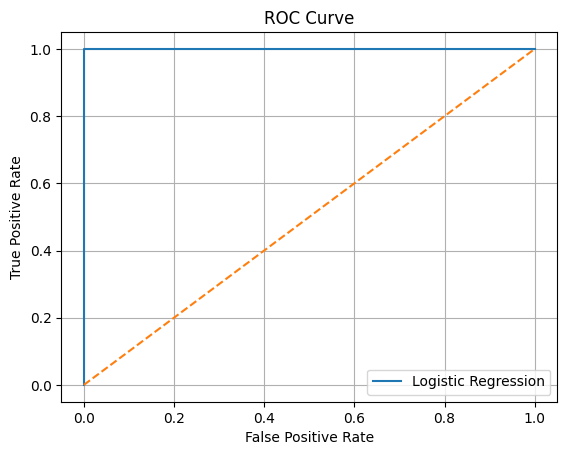

In [61]:
plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
# View the Coefficients ("Weights")
coefficients_ridge = pd.DataFrame({'Feature': X.columns,'Coefficient': Ridge_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

coefficients_ridge

,Feature,Coefficient
0,Vascular_Marker,1.828451
1,Total_ROS,-1.862107


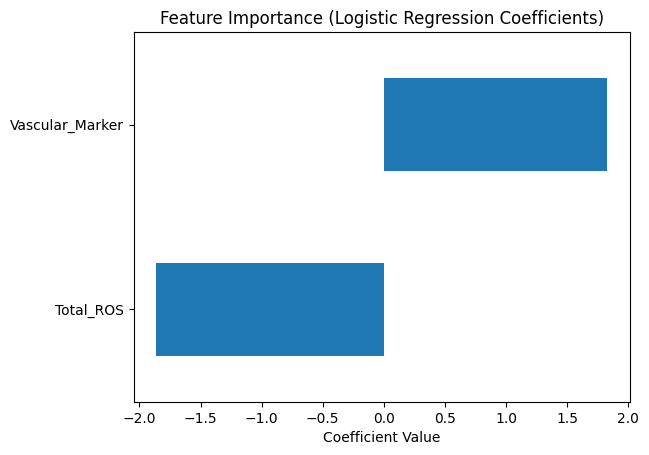

In [63]:
# Feature Importance
feature_importance_ridge = pd.Series(Ridge_model.coef_[0], index=X.columns).sort_values()

plt.figure()
feature_importance_ridge.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

# Clustering Analysis
Clustering analysis is an unsupervised learning technique used to group similar data points into clusters.
Data points within the same cluster are more similar to each other than to points in other clusters.

## 1). K-Means Clustering
###### Divides data into K clusters, where K is predefined. Each cluster has a centroid (average position of all points). Assigns each data point to the nearest centroid.
###### Within-Cluster Sum of Squares (WCSS) before clustering, which helps determine the optimal number of clusters using the Elbow Method.

*   Know how many clusters you need. Works best for well-separated, spherical clusters. Fast and scalable for large datasets.

*   Sensitive to the choice of K. Struggles with non-spherical clusters. Can be affected by outliers.



In [184]:
df = pd.read_csv("train_data.csv")

In [185]:
# Shuffle original dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [186]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group
0,74,0.30,2.2,61,47,31,33,0
1,20,1.20,1.0,100,80,100,70,1
2,73,0.20,1.7,67,45,44,32,0
3,22,1.20,0.8,96,79,92,72,1
4,79,0.19,1.8,70,43,41,28,0
...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1
80,87,1.80,2.2,73,44,35,33,0
81,56,0.14,1.5,71,52,42,17,0
82,24,1.30,1.1,98,79,98,83,1


In [187]:
X = df.drop(columns=["Group"])
y = df["Group"]

In [188]:
X

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery
0,74,0.30,2.2,61,47,31,33
1,20,1.20,1.0,100,80,100,70
2,73,0.20,1.7,67,45,44,32
3,22,1.20,0.8,96,79,92,72
4,79,0.19,1.8,70,43,41,28
...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71
80,87,1.80,2.2,73,44,35,33
81,56,0.14,1.5,71,52,42,17
82,24,1.30,1.1,98,79,98,83


In [189]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [190]:
X_scaled

array([[ 1.04303750e+00, -9.50034550e-01,  1.14622945e+00,
        -1.47806189e+00, -9.78839368e-01, -1.26999064e+00,
        -7.44928171e-01],
       [-1.00866159e+00,  4.11531554e-01, -6.64741215e-01,
         1.55775676e+00,  6.04207731e-01,  1.12612452e+00,
         6.65941271e-01],
       [ 1.00504307e+00, -1.10131967e+00,  3.91658337e-01,
        -1.01101287e+00, -1.07478162e+00, -8.18548657e-01,
        -7.83059777e-01],
       [-9.32672737e-01,  4.11531554e-01, -9.66569658e-01,
         1.24639075e+00,  5.56236607e-01,  8.48314062e-01,
         7.42204485e-01],
       [ 1.23300964e+00, -1.11644818e+00,  5.42572559e-01,
        -7.77488354e-01, -1.17072386e+00, -9.22727577e-01,
        -9.35586203e-01],
       [ 5.87104371e-01, -9.19777525e-01,  5.42572559e-01,
        -5.43963843e-01, -1.02681049e+00, -1.02690650e+00,
        -1.08811263e+00],
       [ 1.08103193e+00, -1.07106265e+00,  8.44401003e-01,
         7.87681885e-02, -8.82897119e-01, -1.23526434e+00,
        -7.8305977

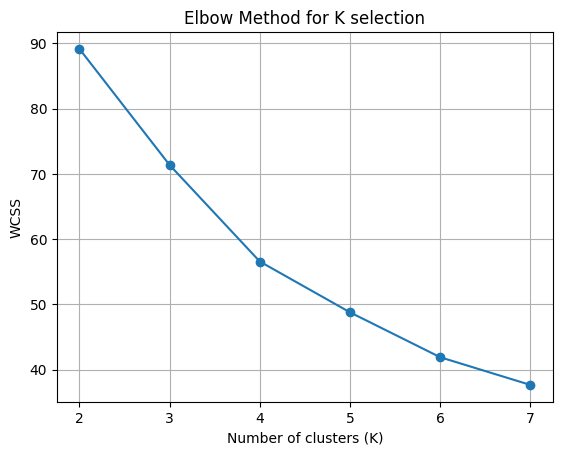

In [191]:
wcss = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, wcss, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K selection")
plt.grid(True)
plt.show()

In [192]:
# WCSS stands for Within-Cluster Sum of Squares. It measures how close the data points are to the center (centroid) of their cluster.
# Small WCSS → points are very close to their centroid
# Large WCSS → points are spread out
# The elbow method shows a sharp decrease in WCSS up to K = 2, after which the curve flattens. Therefore, K = 2 is chosen as the optimal number of clusters.

## For two cluster

In [193]:
kmeans_model1 = KMeans(n_clusters=2, init="k-means++", n_init=50, random_state=42)
cluster_2 = kmeans_model1.fit_predict(X_scaled)

df["Cluster_2"] = cluster_2

In [194]:
ari = adjusted_rand_score(y, cluster_2)
print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 1.0


In [195]:
# Every data point is placed in the correct cluster.

In [196]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Cluster_2
0,74,0.30,2.2,61,47,31,33,0,0
1,20,1.20,1.0,100,80,100,70,1,1
2,73,0.20,1.7,67,45,44,32,0,0
3,22,1.20,0.8,96,79,92,72,1,1
4,79,0.19,1.8,70,43,41,28,0,0
...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1
80,87,1.80,2.2,73,44,35,33,0,0
81,56,0.14,1.5,71,52,42,17,0,0
82,24,1.30,1.1,98,79,98,83,1,1


In [197]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

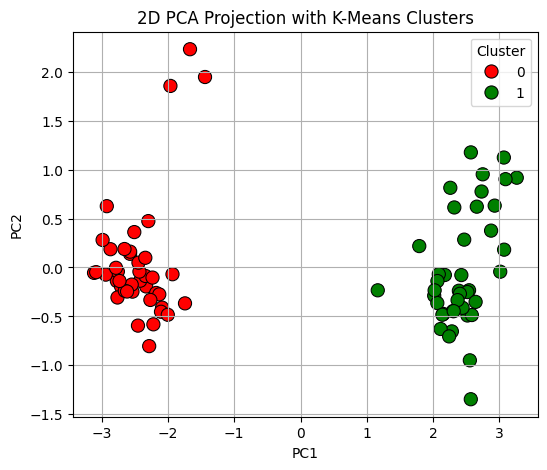

In [198]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Cluster": df["Cluster_2"]
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["red", "green"], s=90, edgecolor="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection with K-Means Clusters")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

In [199]:
# The K-Means algorithm has divided the data into two clusters based on similarity.
# The two clusters are clearly separated, mainly along PC1, showing that K-Means has successfully identified two distinct groups.
# The points of one cluster do not mix or cross with the points of the other cluster.
# There is a clear gap (empty space) between the two clusters.
# Because the points are separated and not mixed, we can say there is little or no overlap.

## For three Cluster

In [200]:
kmeans_model2 = KMeans(n_clusters=3, init="k-means++", n_init=50, random_state=42)
cluster_3 = kmeans_model2.fit_predict(X_scaled)

df["Cluster_3"] = cluster_3

In [201]:
ari = adjusted_rand_score(y, cluster_3)
print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 0.9328102621582913


In [202]:
# The ARI is less than 1 because one cluster contains an outlier point (blue cluster), which slightly reduces the match with true labels.

In [203]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Cluster_2,Cluster_3
0,74,0.30,2.2,61,47,31,33,0,0,0
1,20,1.20,1.0,100,80,100,70,1,1,1
2,73,0.20,1.7,67,45,44,32,0,0,0
3,22,1.20,0.8,96,79,92,72,1,1,1
4,79,0.19,1.8,70,43,41,28,0,0,0
...,...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1,1
80,87,1.80,2.2,73,44,35,33,0,0,2
81,56,0.14,1.5,71,52,42,17,0,0,0
82,24,1.30,1.1,98,79,98,83,1,1,1


In [204]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

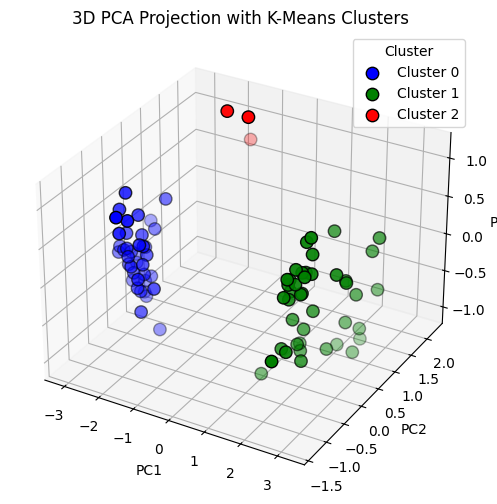

In [205]:
# Prepare PCA DataFrame
pca_df_3d = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Cluster": df["Cluster_3"]
})

# Color map for clusters
cluster_colors = {
    0: "blue",
    1: "green",
    2: "red"
}

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

# Plot each cluster separately with fixed colors
for cluster_label in sorted(pca_df_3d["Cluster"].unique()):
    subset = pca_df_3d[pca_df_3d["Cluster"] == cluster_label]
    ax.scatter(subset["PC1"], subset["PC2"], subset["PC3"], s=80, edgecolor="black", color=cluster_colors[cluster_label], label=f"Cluster {cluster_label}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection with K-Means Clusters")

ax.legend(title="Cluster")
plt.show()

In [206]:
# The K-Means algorithm has divided the data into three clusters based on similarity.
# In the 3D PCA plot (PC1, PC2, PC3), the three clusters are clearly separated in space.
# Each cluster lies in a different region of the PCA space, mainly separated along PC1, with additional separation from PC2 and PC3.
# The points of one cluster do not mix with points of the other clusters.
# There is visible empty space between the clusters.
# Because the clusters are separated and not mixed, we can say there is little or no overlap between them.
# The blue point, which belongs to unhealthy group, is far away from the other clusters in the PCA space, mainly due to its very high LDL uptake value.

In [207]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

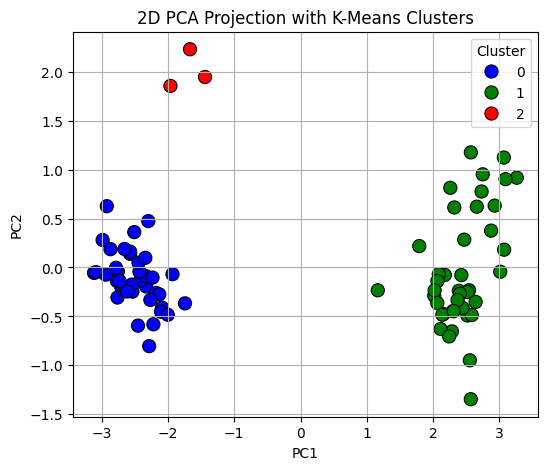

In [208]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Cluster": df["Cluster_3"]
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["blue", "green", "red"], s=90, edgecolor="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection with K-Means Clusters")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

# 2). Gaussian Mixture Model (GMM)
##### Unlike hard clustering methods (e.g., K-Means), GMM performs soft clustering, meaning each data point is assigned a probability of belonging to each cluster rather than a single fixed label. GMM assumes that each cluster follows a Gaussian (normal) distribution. Because of this, clusters can overlap, and the boundaries between clusters are not strict.


*   If data isn’t clearly separable. If clusters are elliptical rather than spherical. Need soft clustering (probabilistic assignment).
*   The number of clusters (K) must be chosen beforehand. It is computationally expensive compared to K-Means.



In [209]:
X_scaled

array([[ 1.04303750e+00, -9.50034550e-01,  1.14622945e+00,
        -1.47806189e+00, -9.78839368e-01, -1.26999064e+00,
        -7.44928171e-01],
       [-1.00866159e+00,  4.11531554e-01, -6.64741215e-01,
         1.55775676e+00,  6.04207731e-01,  1.12612452e+00,
         6.65941271e-01],
       [ 1.00504307e+00, -1.10131967e+00,  3.91658337e-01,
        -1.01101287e+00, -1.07478162e+00, -8.18548657e-01,
        -7.83059777e-01],
       [-9.32672737e-01,  4.11531554e-01, -9.66569658e-01,
         1.24639075e+00,  5.56236607e-01,  8.48314062e-01,
         7.42204485e-01],
       [ 1.23300964e+00, -1.11644818e+00,  5.42572559e-01,
        -7.77488354e-01, -1.17072386e+00, -9.22727577e-01,
        -9.35586203e-01],
       [ 5.87104371e-01, -9.19777525e-01,  5.42572559e-01,
        -5.43963843e-01, -1.02681049e+00, -1.02690650e+00,
        -1.08811263e+00],
       [ 1.08103193e+00, -1.07106265e+00,  8.44401003e-01,
         7.87681885e-02, -8.82897119e-01, -1.23526434e+00,
        -7.8305977

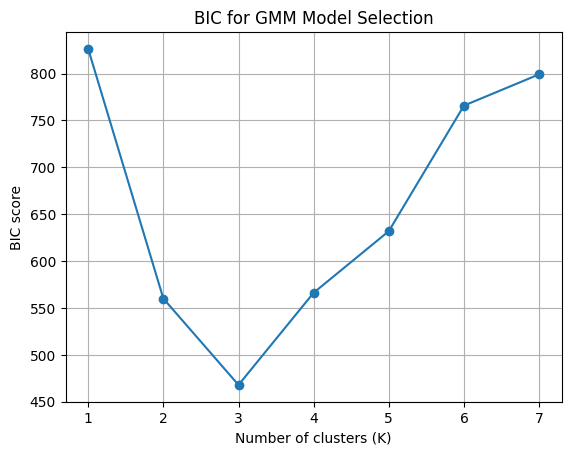

In [210]:
bic_scores = []
components = range(1, 8)

for k in components:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(components, bic_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("BIC score")
plt.title("BIC for GMM Model Selection")
plt.grid(True)
plt.show()

## For Two Cluster

In [211]:
gmm1_model = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm1_labels = gmm1_model.fit_predict(X_scaled)

df["GMM_Cluster2"] = gmm1_labels

In [212]:
ari = adjusted_rand_score(y, gmm1_labels)
print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 1.0


In [213]:
# ARI is 1 means every data point is placed in the correct cluster.

In [214]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Cluster_2,Cluster_3,GMM_Cluster2
0,74,0.30,2.2,61,47,31,33,0,0,0,0
1,20,1.20,1.0,100,80,100,70,1,1,1,1
2,73,0.20,1.7,67,45,44,32,0,0,0,0
3,22,1.20,0.8,96,79,92,72,1,1,1,1
4,79,0.19,1.8,70,43,41,28,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1,1,1
80,87,1.80,2.2,73,44,35,33,0,0,2,0
81,56,0.14,1.5,71,52,42,17,0,0,0,0
82,24,1.30,1.1,98,79,98,83,1,1,1,1


In [215]:
df = df.drop(columns=["Cluster_2", "Cluster_3"])

In [216]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,GMM_Cluster2
0,74,0.30,2.2,61,47,31,33,0,0
1,20,1.20,1.0,100,80,100,70,1,1
2,73,0.20,1.7,67,45,44,32,0,0
3,22,1.20,0.8,96,79,92,72,1,1
4,79,0.19,1.8,70,43,41,28,0,0
...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1
80,87,1.80,2.2,73,44,35,33,0,0
81,56,0.14,1.5,71,52,42,17,0,0
82,24,1.30,1.1,98,79,98,83,1,1


In [217]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

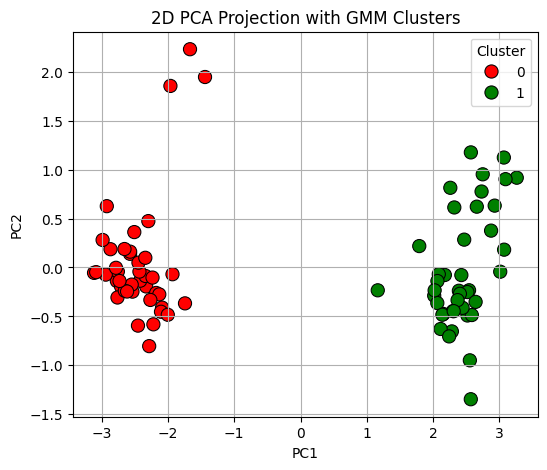

In [218]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Cluster": df["GMM_Cluster2"]
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["red", "green"], s=90, edgecolor="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection with GMM Clusters")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

## For Three Cluster

In [219]:
gmm2_model = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm2_labels = gmm2_model.fit_predict(X_scaled)

df["GMM_Cluster3"] = gmm2_labels

In [220]:
ari = adjusted_rand_score(y, gmm2_labels)
print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 0.9328102621582913


In [221]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,GMM_Cluster2,GMM_Cluster3
0,74,0.30,2.2,61,47,31,33,0,0,0
1,20,1.20,1.0,100,80,100,70,1,1,1
2,73,0.20,1.7,67,45,44,32,0,0,0
3,22,1.20,0.8,96,79,92,72,1,1,1
4,79,0.19,1.8,70,43,41,28,0,0,0
...,...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1,1
80,87,1.80,2.2,73,44,35,33,0,0,2
81,56,0.14,1.5,71,52,42,17,0,0,0
82,24,1.30,1.1,98,79,98,83,1,1,1


In [222]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

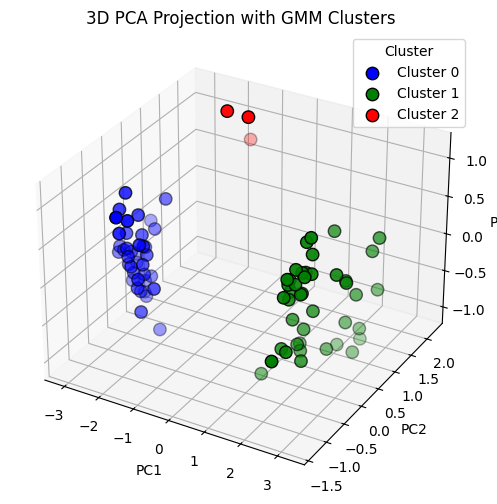

In [223]:
# Prepare PCA DataFrame
pca_df_3d = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Cluster": df["GMM_Cluster3"]
})

# Color map for clusters
cluster_colors = {
    0: "blue",
    1: "green",
    2: "red"
}

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

# Plot each cluster separately with fixed colors
for cluster_label in sorted(pca_df_3d["Cluster"].unique()):
    subset = pca_df_3d[pca_df_3d["Cluster"] == cluster_label]
    ax.scatter(subset["PC1"], subset["PC2"], subset["PC3"], s=80, edgecolor="black", color=cluster_colors[cluster_label], label=f"Cluster {cluster_label}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection with GMM Clusters")

ax.legend(title="Cluster")
plt.show()

In [224]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

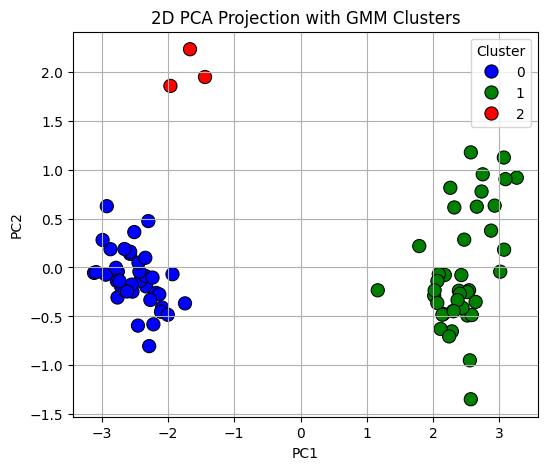

In [225]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Cluster": df["GMM_Cluster3"]
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["blue", "green", "red"], s=90, edgecolor="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection with GMM Clusters")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

# 3). Hierarchical Clustering
###### Hierarchical clustering is an unsupervised learning method used to group similar data points into clusters.
###### It creates a tree-like structure called a dendrogram, which shows how clusters are formed step by step.
###### Unlike K-Means, hierarchical clustering does not require the number of clusters to be fixed in advance.
###### a). Agglomerative (Bottom to Up) --> Starts with each data point as a separate cluster, closest clusters are merged repeatedly and ends with one large cluster.
###### b). Divisive (Top to Down) --> Starts with all data points in one cluster, clusters are split repeatedly.
##### Don’t know how many clusters exist. Want a visual representation (dendrogram). Good for small to medium datasets.
###### Computationally expensive for large datasets. Not great for very high-dimensional data.
### Dendrogram

*   A dendrogram is a graphical representation of hierarchical clustering. Height represents distance between clusters.
*   Cutting the dendrogram at a certain height gives the number of clusters.



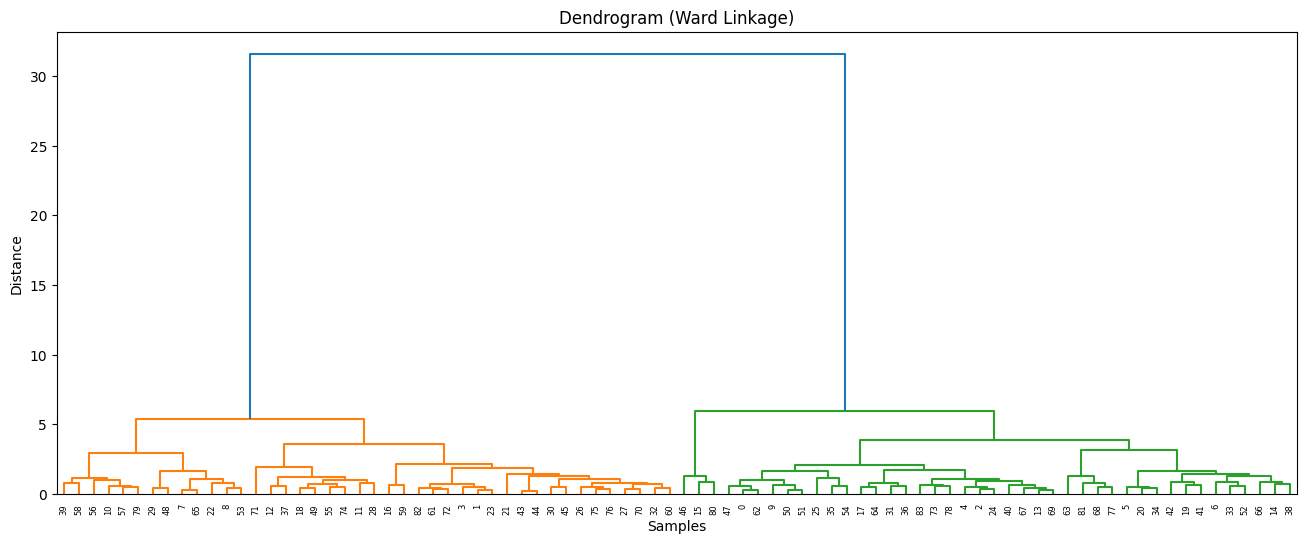

In [226]:
# Dendrogram to decide K
plt.figure(figsize=(16, 6))
sch.dendrogram(sch.linkage(X_scaled, method="ward"))
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [227]:
# The dendrogram shows how samples are merged step by step based on similarity.
# Two main clusters are formed because there is a large vertical distance between the final merge.
# Samples within each cluster are merged at low distances, showing they are very similar to each other.
# The large gap in height before the final merge indicates a strong separation between the two clusters.
# Therefore, cutting the dendrogram at this height gives two meaningful clusters.

In [228]:
# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
df["Cluster_Agglomerative"] = agg.fit_predict(X_scaled)

In [229]:
ari = adjusted_rand_score(y, df["Cluster_Agglomerative"])
print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 1.0


In [230]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,GMM_Cluster2,GMM_Cluster3,Cluster_Agglomerative
0,74,0.30,2.2,61,47,31,33,0,0,0,0
1,20,1.20,1.0,100,80,100,70,1,1,1,1
2,73,0.20,1.7,67,45,44,32,0,0,0,0
3,22,1.20,0.8,96,79,92,72,1,1,1,1
4,79,0.19,1.8,70,43,41,28,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1,1,1
80,87,1.80,2.2,73,44,35,33,0,0,2,0
81,56,0.14,1.5,71,52,42,17,0,0,0,0
82,24,1.30,1.1,98,79,98,83,1,1,1,1


In [231]:
df = df.drop(columns=["GMM_Cluster2", "GMM_Cluster3"])

In [232]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Cluster_Agglomerative
0,74,0.30,2.2,61,47,31,33,0,0
1,20,1.20,1.0,100,80,100,70,1,1
2,73,0.20,1.7,67,45,44,32,0,0
3,22,1.20,0.8,96,79,92,72,1,1
4,79,0.19,1.8,70,43,41,28,0,0
...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1
80,87,1.80,2.2,73,44,35,33,0,0
81,56,0.14,1.5,71,52,42,17,0,0
82,24,1.30,1.1,98,79,98,83,1,1


In [168]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

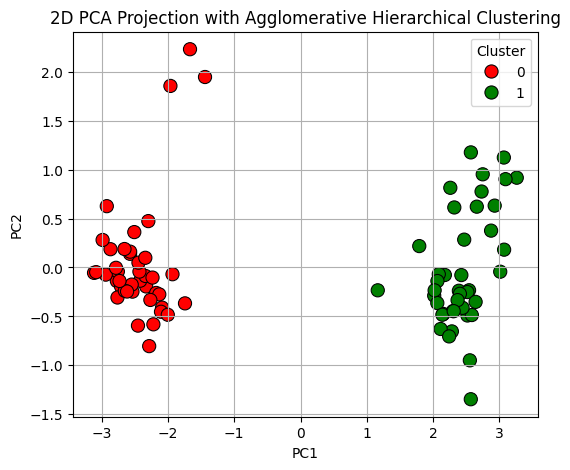

In [233]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Cluster": df["Cluster_Agglomerative"]
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["red", "green"], s=90, edgecolor="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection with Agglomerative Hierarchical Clustering")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

In [170]:
# Agglomerative hierarchical clustering has divided the data into two clusters based on similarity.
# In the PCA plot, the two clusters are clearly separated, mainly along PC1.
# The points of one cluster (green) are on the left side, while the points of the other cluster (red) are on the right side.
# There is no mixing of points between the two clusters.
# The clear gap between the clusters shows very little or no overlap.
# This confirms that agglomerative clustering has successfully identified two distinct groups.

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

In [234]:
dbscan = DBSCAN(
    eps=1.3,        # needs tuning
    min_samples=3,  # reasonable for small N
    metric="euclidean"
)

clusters = dbscan.fit_predict(X_scaled)
# DBSCAN assigns "-1" to noise points that do not belong to any cluster.

In [235]:
df["DBSCAN_cluster"] = clusters

In [236]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,Cluster_Agglomerative,DBSCAN_cluster
0,74,0.30,2.2,61,47,31,33,0,0,0
1,20,1.20,1.0,100,80,100,70,1,1,1
2,73,0.20,1.7,67,45,44,32,0,0,0
3,22,1.20,0.8,96,79,92,72,1,1,1
4,79,0.19,1.8,70,43,41,28,0,0,0
...,...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1,1
80,87,1.80,2.2,73,44,35,33,0,0,2
81,56,0.14,1.5,71,52,42,17,0,0,0
82,24,1.30,1.1,98,79,98,83,1,1,1


In [237]:
df = df.drop(columns=["Cluster_Agglomerative"])

In [238]:
df

,Permeability,LDL_uptake,Total_ROS,Vascular_Marker,Cell_Signalling,Tube_formation,In_vivo_recovery,Group,DBSCAN_cluster
0,74,0.30,2.2,61,47,31,33,0,0
1,20,1.20,1.0,100,80,100,70,1,1
2,73,0.20,1.7,67,45,44,32,0,0
3,22,1.20,0.8,96,79,92,72,1,1
4,79,0.19,1.8,70,43,41,28,0,0
...,...,...,...,...,...,...,...,...,...
79,12,1.80,0.6,84,91,96,71,1,1
80,87,1.80,2.2,73,44,35,33,0,2
81,56,0.14,1.5,71,52,42,17,0,0
82,24,1.30,1.1,98,79,98,83,1,1


In [242]:
df["DBSCAN_cluster"].value_counts()

,count
DBSCAN_cluster,
1,42
0,39
2,3


In [239]:
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

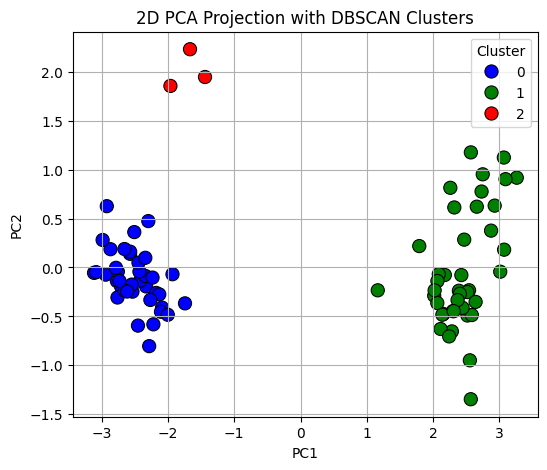

In [241]:
# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Cluster": df["DBSCAN_cluster"]
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["blue", "green", "red",], s=90, edgecolor="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection with DBSCAN Clusters")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()